# FlashEats — Class 5 Investigation

## Client escalation

> **“Late deliveries are increasing and customers say our ETA is unreliable. Figure out what is happening before we invest in an AI delay-prediction system.”**

Today is not a syntax lesson. Your job is to use SQL, CSV, JSON and APIs like an FDE:

**define the question → retrieve evidence → validate completeness → reconcile sources → state what you know and what you still cannot know**

### Rules
- Do not train an ML model.
- State your definition of **late** before calculating it.
- Preserve raw API responses.
- Do not silently drop failures.
- If another team gets a different answer, investigate the definition and data grain first.

In [1]:
# Local, offline setup — uses only this workspace
import json, logging, sqlite3, subprocess, sys, time
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import requests

START = Path.cwd().resolve()
ROOT = next((path for path in (START, *START.parents)
             if (path / "data" / "raw" / "flasheats.db").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("Could not find the repository root above the working directory")
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "src"))

from challenges.notebook_support import (
    build_order_timeline, class7_order_model, lateness_view, load_context,
    normalize_ticket_category,
)

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 140)
ctx = load_context()
print("Workspace:", ROOT)
print("Published pipeline gate:", ctx["quality_report"]["gate"])


Workspace: /home/subaru/fde-work/FDE-Assignment-2
Published pipeline gate: WARN


In [2]:
# 1. LOCAL CLASSROOM DATA
BASE = ROOT
RAW = ROOT / "data" / "raw"
PUBLISHED = ROOT / "data" / "processed" / "run_date=2026-09-27"
print("RAW:", RAW, "exists:", RAW.exists())
print("Published evidence:", PUBLISHED, "exists:", PUBLISHED.exists())

RAW: /home/subaru/fde-work/FDE-Assignment-2/data/raw exists: True
Published evidence: /home/subaru/fde-work/FDE-Assignment-2/data/processed/run_date=2026-09-27 exists: True


## 2. Source map first

Before analysis, predict where you would look for:

| Information | Likely source | Why? |
|---|---|---|
| Promised delivery time |  |  |
| Actual delivery time |  |  |
| Driver assignment |  |  |
| Customer complaint |  |  |
| Restaurant status |  |  |
| Driver movement/events |  |  |

**Discuss:** Which source is authoritative for each fact, and which is only contextual?

### Completed source map

| Information | Authoritative source used | Contextual/corroborating source |
|---|---|---|
| Promised delivery time | SQLite `orders.promised_eta` | Dispatch current ETA is mutable |
| Actual delivery time | SQLite `orders.actual_delivery_at` | order events and telemetry |
| Driver assignment | Dispatch API snapshot | SQLite order driver / telemetry assignment |
| Customer complaint | `support_tickets.csv` | customer interaction/app-action records |
| Restaurant status | `restaurant_status.csv` | order pickup milestone |
| Driver movement/events | `driver_events.json` | dispatch assignment fields |

Authority is field-specific and source ownership is not independently verified. The pipeline therefore preserves disagreements instead of silently selecting a value.

In [3]:
# 3. READ EVERY LOCAL SOURCE (SQLite, CSV, nested JSON)
db_path = RAW / "flasheats.db"
con = sqlite3.connect(f"{db_path.resolve().as_uri()}?mode=ro", uri=True)
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table' ORDER BY name", con)
display(tables)
sample_orders = pd.read_sql("SELECT * FROM orders LIMIT 5", con)
display(sample_orders)
tickets = ctx["support_tickets"]
restaurant_status = ctx["restaurant_status"]
driver_events = ctx["driver_events"]
print("Tickets:", tickets.shape, "restaurant status:", restaurant_status.shape,
      "driver objects:", len(driver_events))
display(tickets.head(3))
display(driver_events[:1])

,name
0,customers
1,drivers
2,orders
3,restaurants


,order_id,customer_id,restaurant_id,driver_id,city,created_at,promised_eta,pickup_at,actual_delivery_at,final_status,distance_km_estimate,traffic_bucket,weather_bucket
0,O00001,C0168,R009,D103,Bengaluru,2026-08-13T12:56:00,2026-08-13T14:11:36,2026-08-13T13:35:49.825561,2026-08-13T14:22:25.035899,delivered,18.00,medium,clear
1,O00002,C0043,R018,D083,Bengaluru,2026-08-01T18:36:00,2026-08-01T19:43:16.627988,2026-08-01T18:58:24.735336,2026-08-01T19:47:14.818533,delivered,9.37,severe,clear
2,O00003,C0855,R010,D039,Bengaluru,2026-08-01T19:35:00,2026-08-01T20:17:52.941967,2026-08-01T19:57:50.820366,2026-08-01T20:13:28.061191,delivered,2.42,medium,clear
3,O00004,C0229,R030,D038,Bengaluru,2026-08-09T18:16:00,2026-08-09T19:30:19.067006,2026-08-09T18:46:48.725485,NaN,cancelled,14.20,high,rain
4,O00005,C0040,R004,D047,Bengaluru,2026-08-06T20:35:00,2026-08-06T21:54:48,2026-08-06T21:18:38.024280,2026-08-06T22:15:49.290713,delivered,18.00,high,clear


Tickets: (202, 5) restaurant status: (502, 4) driver objects: 120


,ticket_id,order_id,created_at,category,customer_message
0,T00001,NaN,2026-08-26T23:34:00,late_delivery,My order is already past the promised time.
1,T00002,NaN,2026-08-24T13:49:00,eta_changed,The ETA keeps changing and the food is still not here.
2,T00003,NaN,2026-08-25T18:22:00,status_mismatch,The app says picking up but the restaurant says it is ready.


[{'driver_id': 'D001',
  'events': [{'order_id': 'O00162',
    'type': 'assigned',
    'timestamp': '2026-08-26T17:53:25.977803'},
   {'order_id': 'O00162',
    'type': 'gps_ping',
    'timestamp': '2026-08-26T18:10:59.372420',
    'lat': 12.826339,
    'lon': 77.448282},
   {'order_id': 'O00162',
    'type': 'gps_ping',
    'timestamp': '2026-08-26T18:28:32.767037',
    'lat': 12.876013,
    'lon': 77.477707},
   {'order_id': 'O00162',
    'type': 'gps_ping',
    'timestamp': '2026-08-26T18:46:06.161653',
    'lat': 12.925686,
    'lon': 77.507133},
   {'order_id': 'O00162',
    'type': 'gps_ping',
    'timestamp': '2026-08-26T19:03:39.556270',
    'lat': 12.97536,
    'lon': 77.536558},
   {'order_id': 'O00162',
    'type': 'picked_up',
    'timestamp': '2026-08-26T18:27:32.131791'},
   {'order_id': 'O00162',
    'type': 'delivered',
    'timestamp': '2026-08-26T19:21:12.950887'},
   {'order_id': 'O00180',
    'type': 'assigned',
    'timestamp': '2026-08-08T18:05:08.439625'},
   {'o

# Challenge 1 — How large is the late-delivery problem?

Before coding, decide:

- **Late means:** ______________________________
- **Denominator:** _____________________________
- **Cancelled orders:** include / exclude / other?
- **Missing actual delivery timestamp:** what will you do?
- **Row grain:** what does one row represent?

### Required analysis
1. valid delivered orders,
2. late count and percentage,
3. median lateness among late orders,
4. worst delayed orders,
5. any data-quality issue that changes the metric.

---

### Completed answer

**Definition.** One row is one canonical business order. “Late” means a normalized delivered order whose observed `actual_delivery_at` is strictly after `promised_eta`. The denominator is delivered orders with both comparable timestamps. Cancelled orders and delivered orders missing completion time are excluded, not labelled on-time.

Result: **843 / 1,495 = 56.39%** late. Median lateness among late orders is **8.03 minutes**. There are 68 cancellations and 37 delivered orders without an actual delivery time. The 1,603 raw rows contain three duplicated IDs; the documented reconciliation keeps one 1,600-order grain, retains both source rows and sets disputed traffic to unknown.


In [4]:
# Challenge 1 — timestamp-derived lateness on the canonical pipeline model
order_analysis = lateness_view(ctx["journey"])
eligible = order_analysis.loc[order_analysis.ldr_eligible].copy()
late = eligible.loc[eligible.late].copy()
summary = pd.DataFrame([{
    "canonical_orders": len(order_analysis), "eligible_delivered": len(eligible),
    "late_orders": len(late), "late_rate": len(late) / len(eligible),
    "median_lateness_among_late_min": late.delay_min.median(),
    "cancelled_excluded": order_analysis.final_status.eq("cancelled").sum(),
    "delivered_missing_actual_excluded": (
        order_analysis.final_status.eq("delivered") & order_analysis.actual_delivery_at.isna()
    ).sum(),
}])
display(summary.round({"late_rate": 4, "median_lateness_among_late_min": 2}))
display(late.nlargest(5, "delay_min")[["order_id", "delay_min", "traffic_bucket", "weather_bucket", "restaurant_id"]])
print("Reconciled traffic conflicts:", ctx["cleaning_report"]["sources"]["orders"]["reconciled_order_ids"])

,canonical_orders,eligible_delivered,late_orders,late_rate,median_lateness_among_late_min,cancelled_excluded,delivered_missing_actual_excluded
0,1600,1495,843,0.5639,8.03,68,37


,order_id,delay_min,traffic_bucket,weather_bucket,restaurant_id
103,O00104,87.345669,medium,clear,R031
101,O00102,86.294363,medium,clear,R004
100,O00101,85.511421,low,rain,R007
102,O00103,69.289038,high,clear,R020
1080,O01081,50.267747,high,clear,R048


Reconciled traffic conflicts: ['O00120', 'O00723', 'O01302']


## Checkpoint

Compare your answer with another team.

If your counts differ, investigate:
- duplicate rows,
- cancelled orders,
- missing timestamps,
- late-delivery definition,
- row grain.

# Challenge 2 — Operations says: “Traffic is the problem.”

Test that claim using at least three dimensions.

Possible dimensions:
- traffic,
- weather,
- distance,
- time of day,
- restaurant,
- driver.

### Required output
- 2–3 comparisons,
- one chart or compact table,
- one hypothesis supported by evidence,
- one alternative explanation you cannot rule out.

Separate **association** from **causation**.

---

### Completed answer

Traffic is associated with delay, but it is not the only observed dimension. After normalizing only the case variant `HIGH`:

| Dimension | Lower/reference | Higher group | Late-rate comparison |
|---|---:|---:|---:|
| Traffic | low | high | 49.44% vs 66.51% |
| Weather | clear | heavy rain | 53.27% vs 73.61% |
| Distance | ≤5 km | >15 km | 53.62% vs 57.96% |

The traffic and weather gaps support investigating adverse conditions; distance is much weaker in these coarse bands. These are associations, not causal effects. Restaurant preparation, dispatch selection, geography, time of day and missing arrival-at-restaurant instrumentation remain plausible confounders.


Traffic


,group,orders,late_orders,late_rate,median_delay_min,mean_delay_min
0,high,424,282,0.6651,3.99,5.29
1,low,360,178,0.4944,-0.09,1.15
2,medium,586,301,0.5137,0.26,2.14
3,severe,122,81,0.6639,4.27,6.42
4,unknown,3,1,0.3333,-6.26,-5.57


Weather


,group,orders,late_orders,late_rate,median_delay_min,mean_delay_min
0,clear,1192,635,0.5327,0.78,2.20
1,heavy_rain,72,53,0.7361,6.63,7.75
2,rain,231,155,0.6710,4.27,6.46


Distance km


,group,orders,late_orders,late_rate,median_delay_min,mean_delay_min
0,<=5,69,37,0.5362,0.59,1.43
1,5-10,222,124,0.5586,1.02,2.57
2,10-15,300,158,0.5267,0.64,2.59
3,>15,904,524,0.5796,1.75,3.57


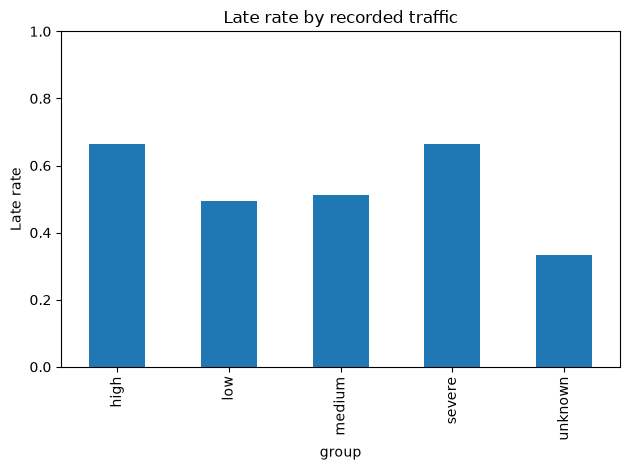

In [5]:
# Challenge 2 — three dimensions on the same eligible population
def dimension_summary(frame, group):
    return (frame.assign(group=group).groupby("group").agg(
        orders=("order_id", "count"), late_orders=("late", "sum"),
        late_rate=("late", "mean"), median_delay_min=("delay_min", "median"),
        mean_delay_min=("delay_min", "mean"),
    ).reset_index())

traffic_summary = dimension_summary(eligible, eligible.traffic_bucket.astype("string").str.strip().str.lower().fillna("unknown"))
weather_summary = dimension_summary(eligible, eligible.weather_bucket.fillna("unknown"))
distance_band = pd.cut(eligible.distance_km_estimate, [-float("inf"),5,10,15,float("inf")], labels=["<=5","5-10","10-15",">15"])
distance_summary = dimension_summary(eligible, distance_band)
for label, table in (("Traffic", traffic_summary), ("Weather", weather_summary), ("Distance km", distance_summary)):
    print(label); display(table.round({"late_rate": 4, "median_delay_min": 2, "mean_delay_min": 2}))
ax = traffic_summary.set_index("group")["late_rate"].plot(kind="bar", ylim=(0,1), title="Late rate by recorded traffic")
ax.set_ylabel("Late rate"); plt.tight_layout(); plt.show()

# Challenge 3 — Customer Support disagrees

Use `support_tickets.csv`.

### Questions
1. What are customers actually complaining about?
2. Which complaint types are most common?
3. Are ticket IDs unique?
4. Does the customer story match the operational story?
5. What can tickets tell you that timestamps cannot?

### Required output
A short **system view vs customer view** comparison.

---

### Completed answer

After safe trim/case/space normalization, complaints are: late delivery **40**, ETA changed **37**, restaurant delay **37**, ready-but-waiting **33**, status mismatch **29**, driver-not-moving **25**, and ETA issue **1**. There are **202 rows, one duplicated ticket ID, and three tickets without an order ID**.

**System view vs customer view:** among eligible deliveries, ticket-linked orders were late **163/197 = 82.74%** with median delay **11.43 min**, versus **680/1,298 = 52.39%** and **0.50 min** without a ticket. Timestamps quantify lateness; tickets expose changing ETAs, perceived lack of movement, status mismatches, restaurant explanations and frustration. Ticketed journeys are self-selected, so this comparison does not estimate a causal effect or overall customer sentiment.


In [6]:
# Challenge 3 — retain raw labels and make only representation normalization
tickets = ctx["support_tickets"].copy()
tickets["category_normalized"] = normalize_ticket_category(tickets.category)
print("Rows:", len(tickets), "duplicate ticket IDs:", tickets.ticket_id.duplicated().sum(),
      "missing order IDs:", tickets.order_id.isna().sum())
display(tickets.category.value_counts(dropna=False).rename("raw_count").to_frame())
display(tickets.category_normalized.value_counts(dropna=False).rename("normalized_count").to_frame())
ticket_orders = set(tickets.order_id.dropna())
ticket_comparison = (eligible.assign(support_ticket=eligible.order_id.isin(ticket_orders))
    .groupby("support_ticket").agg(orders=("order_id","count"), late_orders=("late","sum"),
        late_rate=("late","mean"), median_delay_min=("delay_min","median"), mean_delay_min=("delay_min","mean")))
display(ticket_comparison.round({"late_rate": 4, "median_delay_min": 2, "mean_delay_min": 2}))

Rows: 202 duplicate ticket IDs: 1 missing order IDs: 3


,raw_count
category,
late_delivery,38
eta_changed,37
restaurant_delay,37
ready_but_waiting,33
status_mismatch,29
driver_not_moving,25
Late Delivery,1
late_delivery,1
ETA issue,1


,normalized_count
category_normalized,
late_delivery,40
eta_changed,37
restaurant_delay,37
ready_but_waiting,33
status_mismatch,29
driver_not_moving,25
eta_issue,1


,orders,late_orders,late_rate,median_delay_min,mean_delay_min
support_ticket,,,,,
False,1298,680,0.5239,0.50,1.93
True,197,163,0.8274,11.43,10.99


# Challenge 4 — Dispatch API: prove you retrieved everything

Your task:
1. start the API,
2. inspect one response,
3. retrieve **all** records,
4. handle pagination,
5. handle retryable failures,
6. save every successful raw page,
7. prove ingestion completeness.

A successful HTTP `200` on one page does **not** prove the job succeeded.

---

### Completed answer

The existing retrying extractor retrieved **8 sequential pages × 200 = 1,600 records**, matching `total_records=1600`, with **1,600 unique order IDs** and exact coverage of the canonical order population. The server deliberately returned HTTP 500 on page 3 and HTTP 429 on page 5 once; both were retried successfully. Each successful response is retained under `data/raw/dispatch/run_date=2026-09-27/page_1.json` through `page_8.json`. Completeness is established by page continuity, stable reported total, final count, uniqueness and ID-set equality—not by a single HTTP 200.


In [7]:
# Start the submission-owned local mock API; never touch a pre-existing process.
api_proc = subprocess.Popen([sys.executable, "-m", "mock_api.server"], cwd=ROOT,
                            stdout=subprocess.DEVNULL, stderr=subprocess.PIPE, text=True)
for _ in range(50):
    if api_proc.poll() is not None:
        raise RuntimeError(f"Mock API exited during startup: {api_proc.stderr.read()}")
    try:
        health = requests.get("http://127.0.0.1:8000/health", timeout=.5)
        if health.ok: break
    except requests.RequestException:
        pass
    time.sleep(.1)
else:
    raise RuntimeError("Mock API did not become healthy")
print(health.status_code, health.json())

200 {'status': 'ok', 'service': 'flasheats-dispatch-api'}


In [8]:
# Inspect one response (inspection is not treated as completeness proof)
API_URL = "http://127.0.0.1:8000/dispatch/orders"
response = requests.get(API_URL, params={"page":1, "page_size":50}, timeout=10)
response.raise_for_status(); payload = response.json()
print({key: payload[key] for key in ("page","page_size","has_more","total_records")})
display(pd.DataFrame(payload["data"]).head(2))

{'page': 1, 'page_size': 50, 'has_more': True, 'total_records': 1600}


,order_id,driver_id,original_driver_id,assigned_at,reassigned_at,estimated_pickup_at,current_delivery_eta,dispatch_status,eta_model_version
0,O00001,D103,D103,2026-08-13T13:01:09.659644,NaN,2026-08-13T13:14:00,2026-08-13T14:19:15.546424,completed,eta-v3.2
1,O00002,D083,D083,2026-08-01T18:37:09.708219,NaN,2026-08-01T18:54:00,2026-08-01T20:01:16.627988,completed,eta-v3.2


In [9]:
# Reuse the completed assignment's bounded retries, schema checks, raw-page preservation,
# page-sequence checks, stable-total checks, uniqueness checks and atomic snapshot publication.
from pipeline.config import PipelineConfig
from pipeline.extract import extract_dispatch_api

logger = logging.getLogger("class5.dispatch")
logger.setLevel(logging.INFO)
if not logger.handlers:
    logger.addHandler(logging.StreamHandler())
config = PipelineConfig(log_level="INFO", max_retries=3, retry_backoff_factor=2,
                        dispatch_api_url="http://127.0.0.1:8000")
dispatch_records = extract_dispatch_api(config.dispatch_api_url, "2026-09-27", config, logger)
page_files = sorted((RAW / "dispatch" / "run_date=2026-09-27").glob("page_*.json"))
assert len(dispatch_records) == 1600 == dispatch_records.order_id.nunique()
assert set(dispatch_records.order_id) == set(order_analysis.order_id)
assert len(page_files) == 8
print("Completeness proof:", {"pages":len(page_files), "records":len(dispatch_records),
      "unique_order_ids":dispatch_records.order_id.nunique(), "missing_ids":0, "duplicate_ids":0})

Extracted Dispatch page | page=1 rows=200 cumulative_rows=200 reported_total=1600


Extracted Dispatch page | page=2 rows=200 cumulative_rows=400 reported_total=1600


Retryable Dispatch HTTP failure | page=3 status=500 attempt=1/3 wait=1.0s


Extracted Dispatch page | page=3 rows=200 cumulative_rows=600 reported_total=1600


Extracted Dispatch page | page=4 rows=200 cumulative_rows=800 reported_total=1600


...

Extracted Dispatch page | page=7 rows=200 cumulative_rows=1400 reported_total=1600


Extracted Dispatch page | page=8 rows=200 cumulative_rows=1600 reported_total=1600


Dispatch extraction evidence | pages=8 records=1600 unique_order_ids=1600 missing_order_ids=0 duplicate_order_ids=0


Published Dispatch raw snapshot | run_date=2026-09-27 pages=8 path=/home/subaru/fde-work/FDE-Assignment-2/data/raw/dispatch/run_date=2026-09-27


Completeness proof: {'pages': 8, 'records': 1600, 'unique_order_ids': 1600, 'missing_ids': 0, 'duplicate_ids': 0}


# Challenge 5 — Can we attribute the delay?

Inspect `driver_events.json`.

Look for:
- assignment,
- GPS pings,
- pickup,
- delivery.

Then answer:

> **Can we reliably tell when the driver arrived at the restaurant?**

Be precise about:
- **Observed** = directly stored.
- **Inferred** = estimated from another signal, such as GPS.

### Required output

| Event / fact | Observed? | Source | Reliability concern |
|---|---|---|---|
| Driver assigned |  |  |  |
| Driver at restaurant |  |  |  |
| Picked up |  |  |  |
| Delivered |  |  |  |

---

### Completed answer

No—driver arrival at the restaurant is not directly observed. The nested file has **10,035 events**: 1,600 assigned, 5,371 GPS pings, 1,532 picked-up and 1,532 delivered, but **zero `driver_arrived_at_restaurant` events**.

| Event/fact | Observed? | Source | Reliability concern |
|---|---|---|---|
| Driver assigned | Yes | telemetry / dispatch | sources can disagree; assignment may change |
| Driver at restaurant | No; GPS-only inference possible | GPS pings | no geofence/arrival event or accuracy contract |
| Picked up | Yes for 1,532 events | telemetry/order events | absent for some orders; source ownership unverified |
| Delivered | Yes for 1,532 telemetry events | telemetry/order timestamp | delivered status and timestamp completeness differ |

Inferring arrival from GPS would require restaurant coordinates, accuracy/geofence rules and a validated sampling policy; none is established here.


In [10]:
# Challenge 5 — inventory observed telemetry, without inventing an arrival event
flat_events = pd.DataFrame([{"driver_id": parent["driver_id"], **event}
    for parent in driver_events for event in parent["events"]])
display(flat_events.head())
display(flat_events.type.value_counts().rename("events").to_frame())
print("Explicit driver_arrived_at_restaurant events:", flat_events.type.eq("driver_arrived_at_restaurant").sum())
reliability = pd.DataFrame([
    ["Driver assigned", "Yes", "telemetry / dispatch", "May be reassigned; sources can disagree"],
    ["Driver at restaurant", "No (GPS inference only)", "GPS pings", "No geofence/accuracy/arrival contract"],
    ["Picked up", "Yes, when present", "telemetry / order events", "Missing for some orders"],
    ["Delivered", "Yes, when present", "telemetry / order timestamp", "Status/timestamp completeness differs"],
], columns=["Event / fact","Observed?","Source","Reliability concern"])
display(reliability)

,driver_id,order_id,type,timestamp,lat,lon
0,D001,O00162,assigned,2026-08-26T17:53:25.977803,NaN,NaN
1,D001,O00162,gps_ping,2026-08-26T18:10:59.372420,12.826339,77.448282
2,D001,O00162,gps_ping,2026-08-26T18:28:32.767037,12.876013,77.477707
3,D001,O00162,gps_ping,2026-08-26T18:46:06.161653,12.925686,77.507133
4,D001,O00162,gps_ping,2026-08-26T19:03:39.556270,12.975360,77.536558


,events
type,
gps_ping,5371
assigned,1600
picked_up,1532
delivered,1532


Explicit driver_arrived_at_restaurant events: 0


,Event / fact,Observed?,Source,Reliability concern
0,Driver assigned,Yes,telemetry / dispatch,May be reassigned; sources can disagree
1,Driver at restaurant,No (GPS inference only),GPS pings,No geofence/accuracy/arrival contract
2,Picked up,"Yes, when present",telemetry / order events,Missing for some orders
3,Delivered,"Yes, when present",telemetry / order timestamp,Status/timestamp completeness differs


# Final FDE synthesis — one slide only

Your final slide must answer:

1. **Problem size** — how large is the late-delivery problem?
2. **Evidence** — what appears related to delay?
3. **Trusted sources** — which sources do you trust for which facts?
4. **Uncertainty** — what can you not determine confidently?
5. **Instrumentation recommendation** — what should FlashEats capture/fix next?
6. **Decision** — would you build the AI delay predictor now? Why or why not?

Use language such as:
- “The data shows…”
- “This is associated with…”
- “We cannot determine…”
- “We would need X before concluding Y…”

---

## Completed one-slide synthesis

- **Problem size:** The data shows **843/1,495 = 56.39%** of eligible delivered orders arrived after the promised ETA; median lateness among late orders was **8.03 min**.
- **Evidence:** High/severe traffic (about **66.5%**) and rain/heavy rain (**67.1%/73.6%**) are associated with higher lateness than low traffic/clear weather (**49.4%/53.3%**). Ticket-linked deliveries are also much later (**82.7% late**), but none of these comparisons proves causation.
- **Trusted facts:** SQLite order timestamps/status define the provisional outcome; Dispatch defines assignment snapshot; tickets define complaints; telemetry defines observed movement/pickup/delivery events.
- **Uncertainty:** KPI ownership/denominator, refunds, source ownership, three disputed traffic values, 37 missing completion times, and the absent driver-arrival milestone.
- **Instrument next:** emit a governed `driver_arrived_at_restaurant`/geofence event with accuracy and timezone; fix status/timestamp completeness; assign a KPI owner and denominator contract.
- **Decision:** **Do not build the AI predictor yet.** First make the target definition publishable and capture the missing milestone; otherwise the model would learn from an unowned label and cannot separate approach time from restaurant wait.

In [11]:
# Cleanup only the child API process created by this notebook
try:
    con.close()
except Exception:
    pass
try:
    api_proc.terminate(); api_proc.wait(timeout=5)
except Exception:
    try: api_proc.kill()
    except Exception: pass
print("Session cleanup complete.")

Session cleanup complete.
